# Proof-of-Concept: Chromatin optimal kappa algorithm, replicate 1

In this notebook, we examine intergenic regions and daughter-specific genes. The goal here is to show that we are indeed identifying daughter-specific changes, in the DSE1-4 genes. While appropriately minimizing false positive effects in control intergenic regions where there should be little change, and little differences between the mother and daughter branches.

We aim to find an optimal kappa value that maximizes signal (of DSE chromatin in DG1 compared to CG1) and minimizes false positives (of intergenic CG1/DG1 differences).

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.utils import mkdir_safe
from src.chromatin_deconvolution_solver import plot_example_fits
from src.chromatin_deconvolution_solver import plot_branches
from src.chromatin_model import plot_prediction
from src.geneset import get_deconvolved_geneset
from src.sgd import get_orfname
from src.RealDataReplication import read_n_fr_b
from src.chromatin_deconvolution_solver import subset_select_highest_G_indices


In [3]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs('distinct')
chromatin_model1 = ChromatinModel(config1)


todo: Loading testing config from replication deconvolution


In [4]:
from src.sgd import get_orfname
from src.sgd import read_nondubious_genes_dataset
from src.chromatin_gamma_search import ChromatinFindOptimalGamma
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

genes = read_nondubious_genes_dataset()

In [5]:
from src.sgd import get_intergenic_regions

# Notebook for comuting intergenic regions
intergenic_regions_df = pd.read_csv('datasets/computed_mnase/intergenic_regions_gene500_chrom1000_min500.csv')

In [13]:
np.random.seed(123)
n = 10

high_cov_regions = intergenic_regions_df[intergenic_regions_df.coverage > 0.95]
random_intergenic_indices = np.random.choice(high_cov_regions.index, 10)
random_intergenic_regions = intergenic_regions_df.loc[random_intergenic_indices]
random_intergenic_regions = random_intergenic_regions.set_index('name')\
    .sort_values(['chromosome', 'mid'])
random_intergenic_names = random_intergenic_regions.index.values
random_intergenic_regions

,chromosome,start,end,length,coverage,mid
name,,,,,,
3_30226,3,29520,30933,1413,0.999292,30226
6_19733,6,19180,20286,1106,0.998190,19733
7_18709,7,16985,20434,3449,0.999710,18709
7_739093,7,738770,739416,646,0.998450,739093
7_1072838,7,1072214,1073463,1249,0.998397,1072838
8_35261,8,34697,35825,1128,0.980479,35261
9_36206,9,35476,36936,1460,0.999315,36206
9_337778,9,336725,338831,2106,0.999525,337778
10_724739,10,724400,725078,678,0.998523,724739


In [7]:
def define_span_using_plus_one(gene_rows, window=500, plus_one_upstream_padding=80):
    """Define the span for deconvolution usin the plus one. Offset to include
    the +1 nucleosome and downstream nucleosomes"""
    plus_one_downstream_offset = window-plus_one_upstream_padding
    
    # Load the plus ones locations for replicate 1 and join
    p1s = pd.read_csv('datasets/computed_mnase/rep1_plus_ones.csv').set_index('orf_name')
    gene_rows_wp1 = gene_rows.join(p1s[['+1']], how='inner')

    # Span will be defined from the [plus_one - 80, plus_one+420]
    # this will include the plus one, plus two and plus 3 nucleosomes
    # control for strand

    # Watson strand
    watson = gene_rows_wp1.strand == '+'
    gene_rows_wp1.loc[watson, 'start_span'] = gene_rows_wp1['+1']-plus_one_upstream_padding
    gene_rows_wp1.loc[watson, 'end_span'] = gene_rows_wp1['+1']+plus_one_downstream_offset

    # Crick strand
    gene_rows_wp1.loc[~watson, 'start_span'] = gene_rows_wp1['+1']-plus_one_downstream_offset
    gene_rows_wp1.loc[~watson, 'end_span'] = gene_rows_wp1['+1']+plus_one_upstream_padding

    return gene_rows_wp1[['gene', 'chr', 'strand', 'start_span', 'end_span']]

def define_intergenic_rows(intergenic_regions_df, random_intergenic_names, window):
    win_2 = window//2
    intergenic_regions_df = intergenic_regions_df.loc[random_intergenic_names].copy()
    intergenic_regions_df['start_span'] = intergenic_regions_df.mid-win_2
    intergenic_regions_df['end_span'] = intergenic_regions_df.mid+win_2
    return intergenic_regions_df

In [8]:
# Now concatenate these two dataframes into a unified list for sweeping

def create_deconvolve_sweep_dataframe(genes_to_deconvolve, intergenics_to_deconvolve):
    """Combine the genes and intergenic rows df to common column names for 
    sweeping"""
    genes_to_deconvolve_to_concat = genes_to_deconvolve.rename(columns={
        'gene': 'name'
    })[['name', 'chr', 'start_span', 'end_span']]

    genes_to_deconvolve_to_concat['group'] = 'gene'
    intergenics_concat = intergenics_to_deconvolve.rename(columns={'chromosome': 'chr'})\
        .reset_index()[['name', 'chr', 'start_span', 'end_span']]
    intergenics_concat['group'] = 'intergenic'
    
    df = pd.concat([genes_to_deconvolve_to_concat, intergenics_concat]).reset_index(drop=True)    
    return df


In [9]:
def create_kappa_sweep_row_df(sweep_row, kappa):
    """Create row for saving to disk"""    
    save_path = f"{output_directory}/{sweep_row['name']}_kappa{kappa:.5f}_F.npy"
    save_row = sweep_row.copy()
    save_row['kappa'] = kappa
    save_row['save_path'] = save_path
    return save_row


In [135]:
from src.sgd import get_orfnames

RIBOSOMAL_GENES = ['RPL1A','RPL1B','RPL2A','RPL2B']
DSE_GENES = ['DSE1', 'DSE2', 'DSE3', 'DSE4']
CONTROL_GENES = ['CLB2', 'CLN2', 'MCM6', 'CDC45']

# four dse genes and four intergenic regions for kappa sweep
gene_names = DSE_GENES
#intergenic_names = random_intergenic_names[:4]
intergenic_names = ['9_337778', '11_67258', '7_18709', '8_35261']

gene_rows = genes.loc[get_orfnames(gene_names)]

In [136]:
window = 500
win_2 = window//2

# Define the set of regions to deconvolve, genes and intergenic
genes_to_deconvolve = define_span_using_plus_one(gene_rows, window=window)
intergenics_to_deconvolve = define_intergenic_rows(random_intergenic_regions,
    intergenic_names, window=window)
sweep_rows_df = create_deconvolve_sweep_dataframe(genes_to_deconvolve, 
    intergenics_to_deconvolve)
sweep_rows_df

,name,chr,start_span,end_span,group
0,DSE1,5,408731.0,409231.0,gene
1,DSE2,8,385136.0,385636.0,gene
2,DSE3,15,818631.0,819131.0,gene
3,DSE4,14,758793.0,759293.0,gene
4,9_337778,9,337528.0,338028.0,intergenic
5,11_67258,11,67008.0,67508.0,intergenic
6,7_18709,7,18459.0,18959.0,intergenic
7,8_35261,8,35011.0,35511.0,intergenic


In [400]:
from src.timer import Timer
from src.find_optimal_kappa_chromatin import DSE_GENES, INTERGENICS
from src.find_optimal_kappa_chromatin import deconvolve_and_plot_region, \
    deconvolve_and_plot_gene

output_directory = 'output/kappa_sweep_dse_and_intergenic_gamma.0076/'
mkdir_safe(output_directory)

# Todo: notebook to find optimal gamma, previously found to be 0.0076
# procedure, fix kappa to large value (to minimize DG1/CG1 differences)
# and compute optimal gamma through sweep of set of regions
gamma = 0.007639

# Define the values of kappa to sweep
num_kappas = 4
k_min, k_max = 1e-4, 1e-1
logks = np.linspace(np.log10(k_min), np.log10(k_max), num_kappas)
kappas = 10**logks

timer = Timer()

from src.geneset import get_deconvolved_geneset
from src.sgd import get_orfname

genes = get_deconvolved_geneset()
meta_rows = []

for k_i, kappa in enumerate(kappas):

    print(f"[{k_i}] Kappa: ", kappa)
    
    for row_index, row in sweep_rows_df.iterrows():
        
        save_row = create_kappa_sweep_row_df(row, kappa)
#         deconvolve_and_plot_region(config1, row.chr, 
#             (row.start_span, row.end_span), gamma=gamma, kappa=kappa, 
#             f_savepath=save_row.save_path, save_plots=False)
        meta_rows.append(save_row)

meta_df = pd.DataFrame(meta_rows).reset_index()
meta_df['gamma'] = gamma
meta_df.to_csv(f'{output_directory}/meta.csv')


Creating directory: output/kappa_sweep_dse_and_intergenic_gamma.0076/...Directory exists. Skipping.
[0] Kappa:  0.0001
[1] Kappa:  0.001
[2] Kappa:  0.01
[3] Kappa:  0.1


In [401]:
meta_df = pd.read_csv(f'{output_directory}/meta.csv')
meta_df

,Unnamed: 0,index,name,chr,start_span,end_span,group,kappa,save_path
0,0,0,DSE1,5,408731.0,409231.0,gene,0.0001,output/kappa_sweep_dse_and_intergenic_gamma.00...
1,1,1,DSE2,8,385136.0,385636.0,gene,0.0001,output/kappa_sweep_dse_and_intergenic_gamma.00...
2,2,2,DSE3,15,818631.0,819131.0,gene,0.0001,output/kappa_sweep_dse_and_intergenic_gamma.00...
3,3,3,DSE4,14,758793.0,759293.0,gene,0.0001,output/kappa_sweep_dse_and_intergenic_gamma.00...
4,4,4,9_337778,9,337528.0,338028.0,intergenic,0.0001,output/kappa_sweep_dse_and_intergenic_gamma.00...
...,...,...,...,...,...,...,...,...,...
163,163,3,DSE4,14,758793.0,759293.0,gene,0.1000,output/kappa_sweep_dse_and_intergenic_gamma.00...
164,164,4,9_337778,9,337528.0,338028.0,intergenic,0.1000,output/kappa_sweep_dse_and_intergenic_gamma.00...
165,165,5,11_67258,11,67008.0,67508.0,intergenic,0.1000,output/kappa_sweep_dse_and_intergenic_gamma.00...
166,166,6,7_18709,7,18459.0,18959.0,intergenic,0.1000,output/kappa_sweep_dse_and_intergenic_gamma.00...


In [833]:
optimal_kapp

NameError: name 'optimal_kapp' is not defined

In [402]:
from src.find_optimal_kappa_chromatin import compute_occupancies_entropies_l2s, plot_snr

occupancy_df, entropies_df, l2s_df = compute_occupancies_entropies_l2s(config1, meta_df)

In [403]:
group_mean_l2s_df = l2s_df[['group', 'entropy_tb_l2', 'occupancy_tb_l2', 'kappa']]\
    .groupby(['group', 'kappa']).mean()

kappa
0.000100    1.620158
0.000141    1.622085
0.000200    1.617855
0.000282    1.636326
0.000398    1.647039
0.000562    1.675826
0.000794    1.725464
0.001122    1.746836
0.001585    1.749243
0.002239    1.736158
0.003162    1.700099
0.004467    1.671130
0.006310    1.612741
0.008913    1.545020
0.012589    1.474008
0.017783    1.403057
0.025119    1.322685
0.035481    1.245099
0.050119    1.174016
0.070795    1.114615
0.100000    1.070801
Name: entropy_tb_l2, dtype: float64


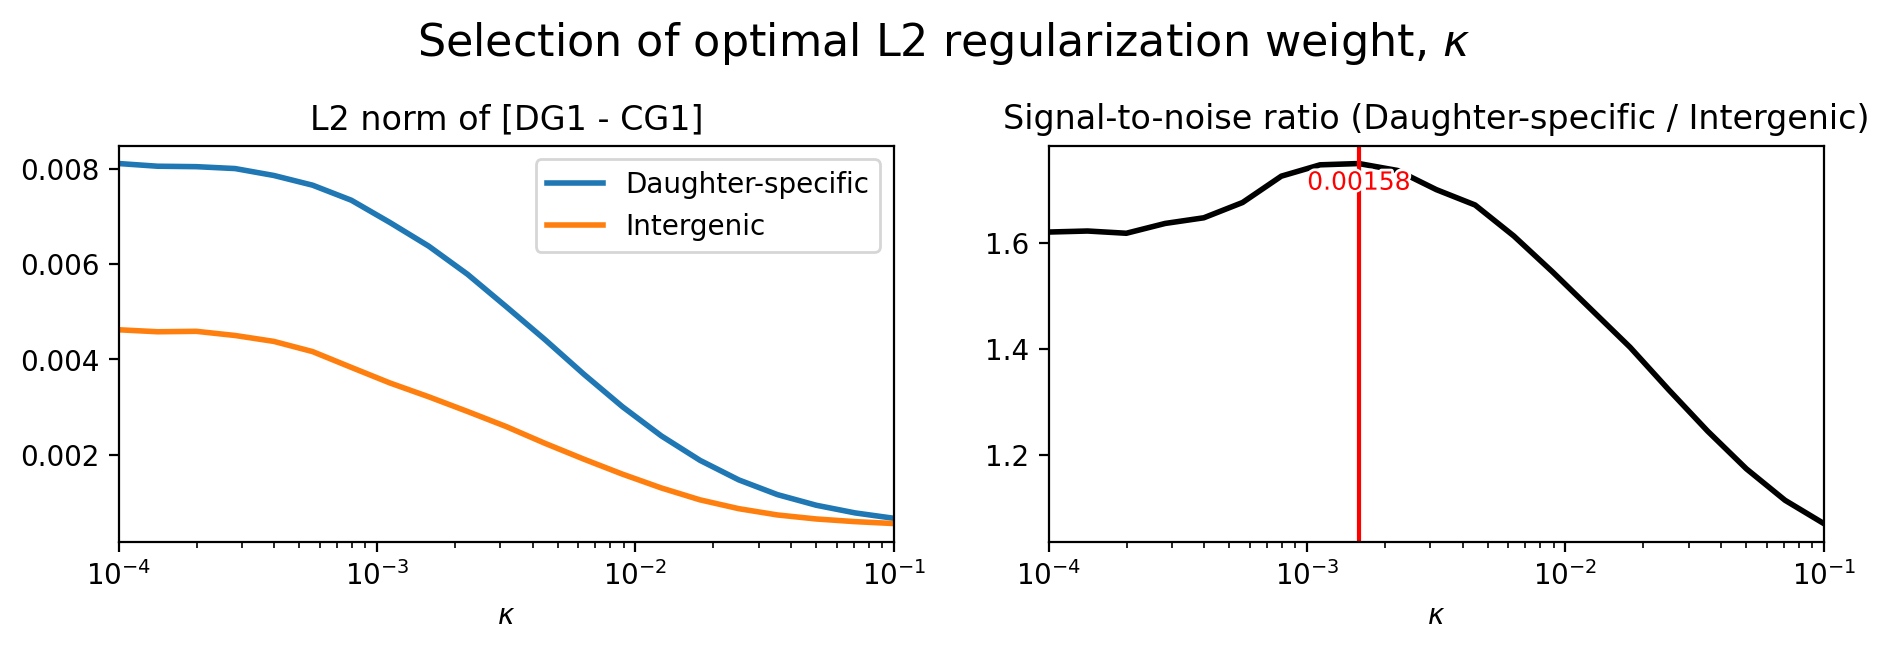

In [404]:
idx_max, kappa_optim, pseudo_eps = plot_snr(group_mean_l2s_df, 'entropy_tb_l2')

In [422]:
kappas = meta_df.kappa.unique()
kappa_optim = kappas[idx_max]
kappa_optim

0.0015848931924611

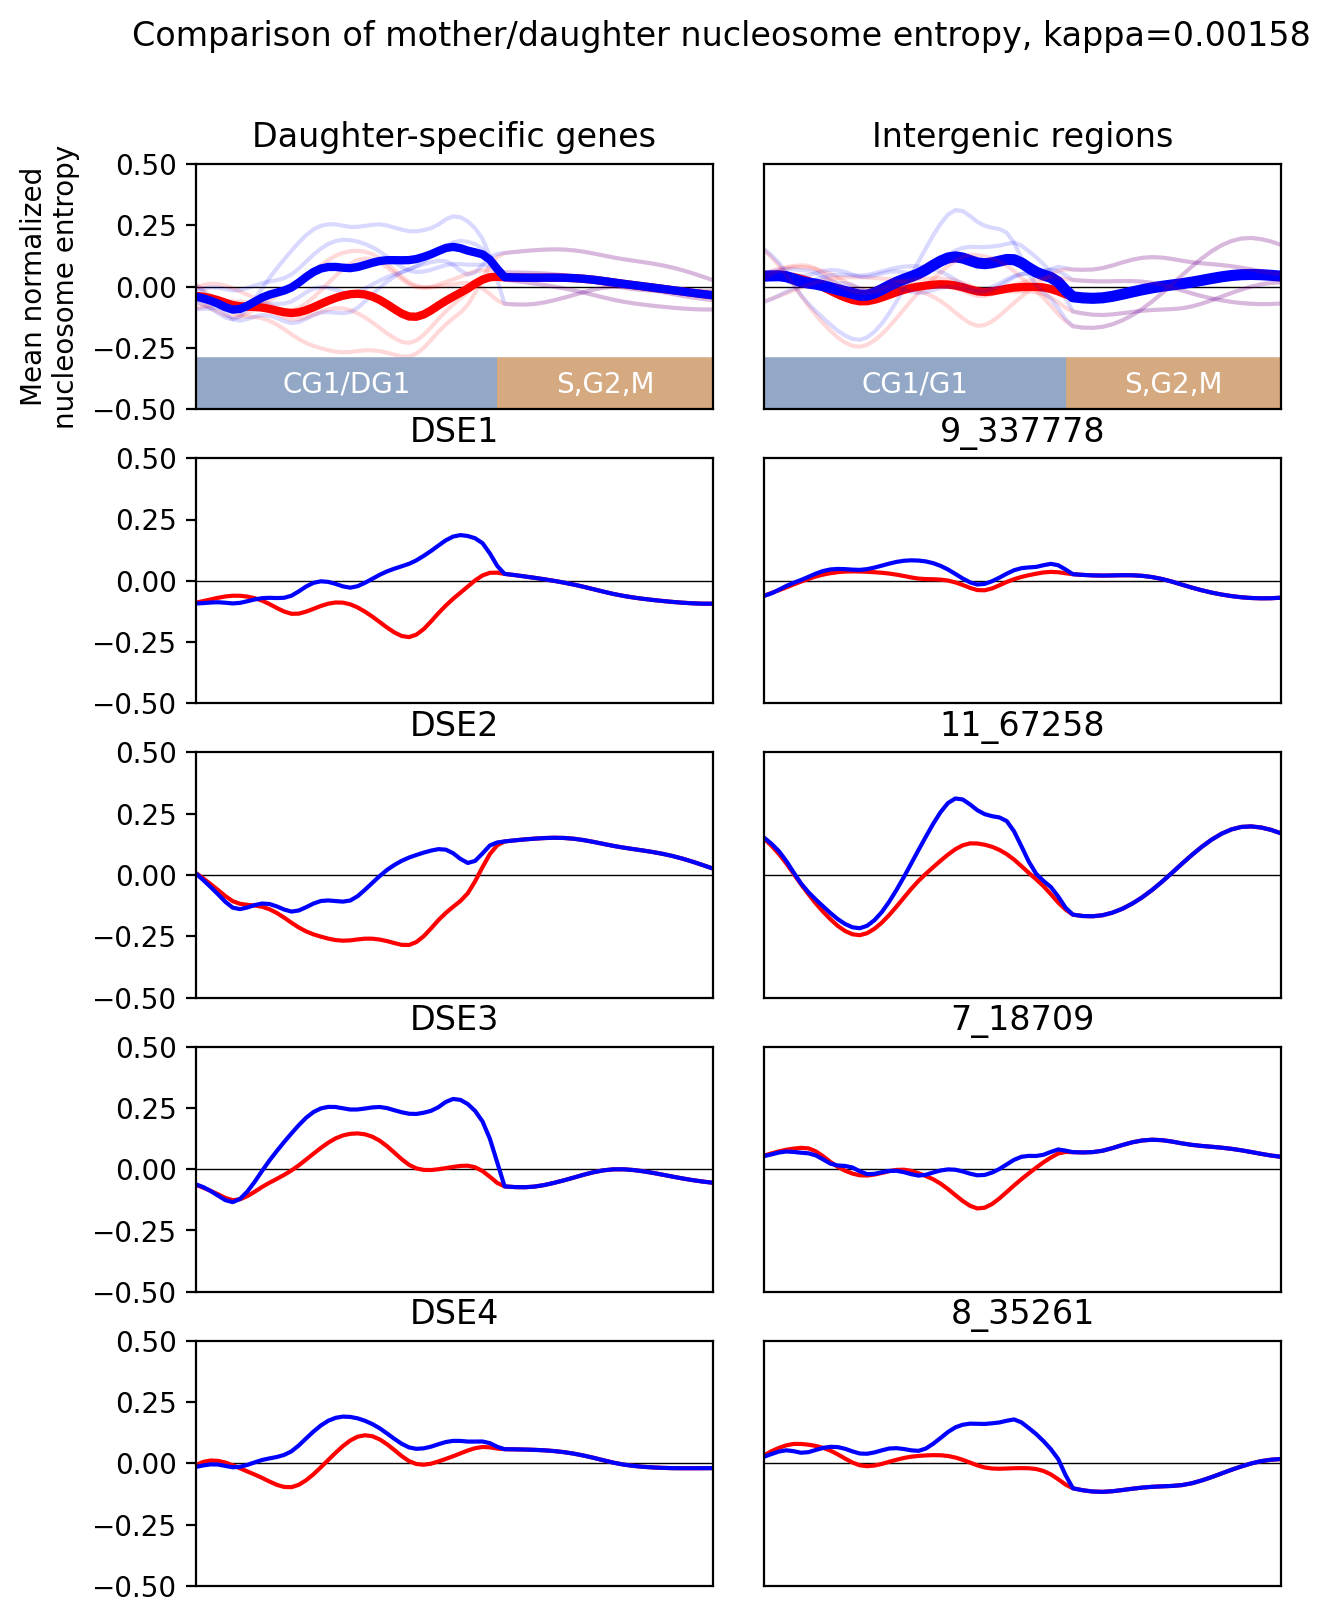

In [423]:
from src.find_optimal_kappa_chromatin import plot_top_bottom_curves

for i in [idx_max]:
    kappa = kappas[i]
    kappa = kappa.round(5)
    fig = plot_top_bottom_curves(config1, kappa, meta_df, entropies_df)
    plt.suptitle(f"Comparison of mother/daughter nucleosome entropy, kappa={kappa}")
    plt.subplots_adjust(top=0.9, wspace=0.1)


In [576]:
from src.geneset import get_deconvolved_geneset
from src.RealDataReplication import read_no_copy_correction_n_fr_b

gene_name = 'DSE1'
genes = get_deconvolved_geneset()
orfname = get_orfname(gene_name)
gene = genes.loc[orfname]
chrom = gene.chr
mid = gene.TSS

window = 1200
padding_2 = window//2

#Intergenic region test
#mid = 337778
#chrom = 9

mnase_span = mid-padding_2, mid+padding_2
N, frep, b = read_no_copy_correction_n_fr_b(config1.H)


In [539]:
from src.chromatin_deconvolution_solver import subset_select_highest_G_indices

chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)


Loading chromosome reads: 5
Applying a normalization for length distribution


In [540]:
#G_values, G_indices = subset_select_highest_G_indices(chromatin_model.G)
G_values = chromatin_model.G

In [541]:
gamma = 0.0076
kappa = 0.001584

chromatin_solver = ChromatinDeconvolveSolver(config1, 
    G_values, N, b, frep)
full_deconvolved_F = chromatin_solver.deconvolve_G_iteratively(gamma=gamma, 
    kappa=kappa, verbose=True)


0/3120 - 00:00:00.002
500/3120 - 00:00:03.354
1000/3120 - 00:01:19.288
1500/3120 - 00:02:51.265
2000/3120 - 00:04:46.343
2500/3120 - 00:06:59.197
3000/3120 - 00:08:55.962
Completed - 00:09:02.645


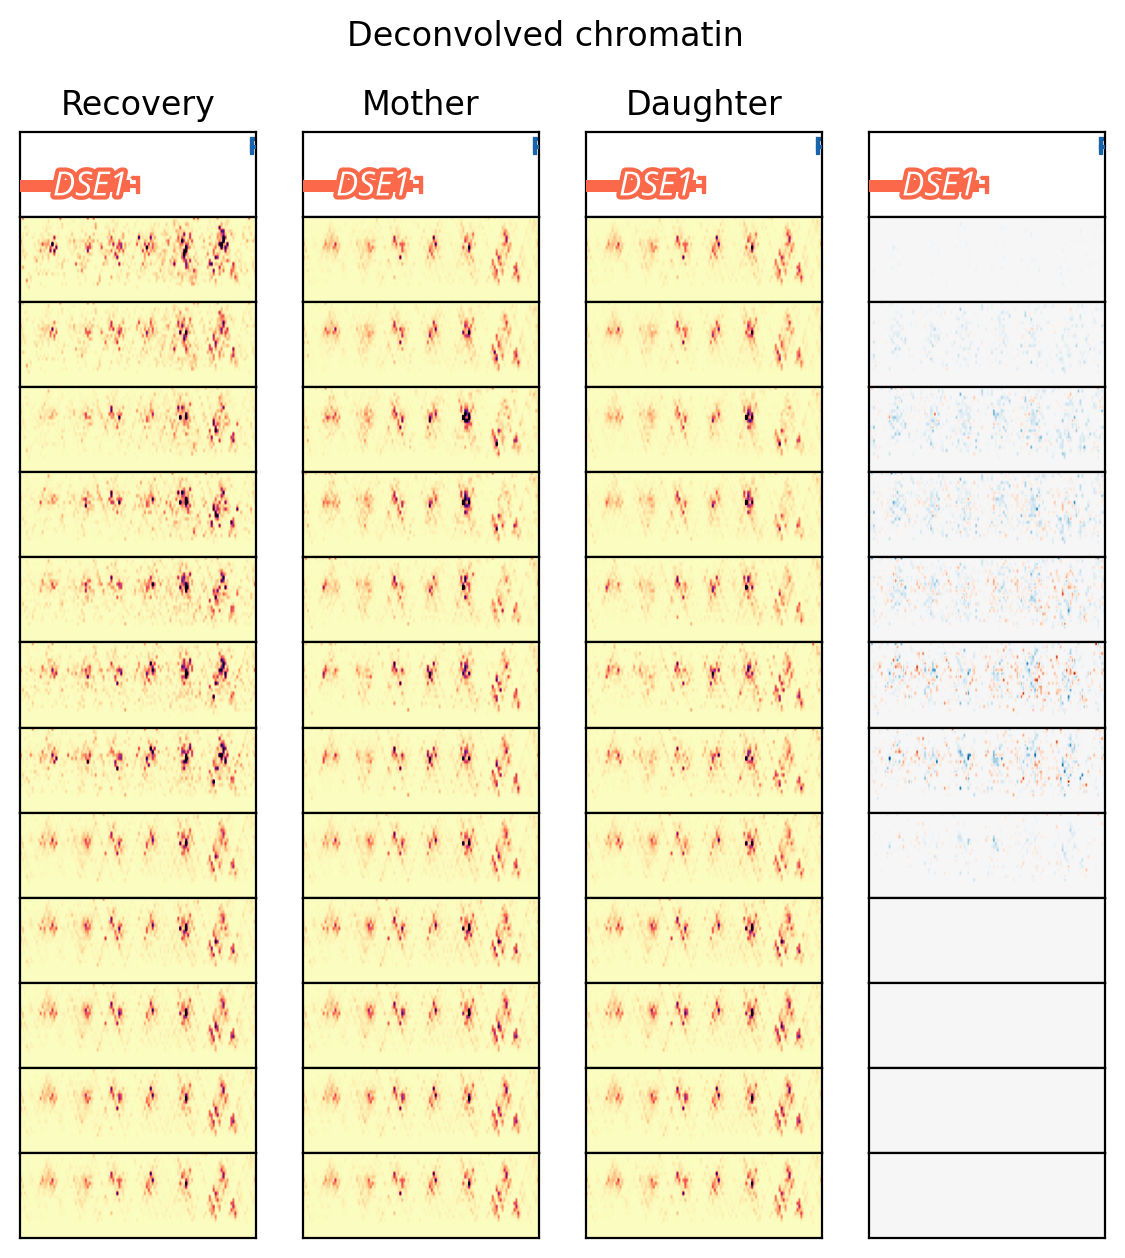

In [577]:
from src.chromatin_deconvolution_solver import plot_branches
fig = plot_branches(config1, chrom, mnase_span, full_deconvolved_F, figsize=(7, 7))


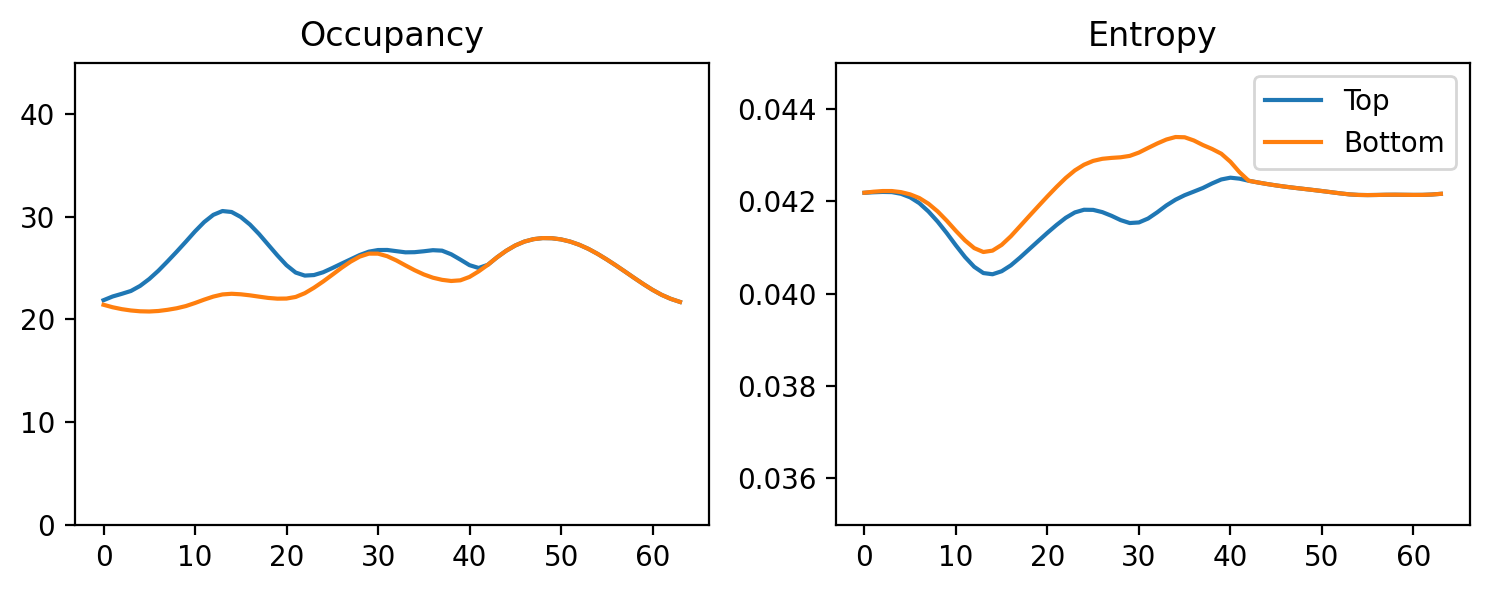

In [574]:
def plot_occupancy_and_entropy(config1, full_deconvolved_F):
    F_imgs = full_deconvolved_F.reshape((full_deconvolved_F.shape[0], 26, -1))
    occ, entr = compute_occupancy_entropy(F_imgs)

    plt.figure(figsize=(9, 3))
    plt.subplot(1, 2, 1)
    plt.plot(occ[config1.t_indices()])
    plt.plot(occ[config1.b_indices()])
    plt.title("Occupancy")
    plt.ylim(0, 45)

    plt.subplot(1, 2, 2)
    plt.plot(entr[config1.t_indices()], label="Top")
    plt.plot(entr[config1.b_indices()], label="Bottom")
    plt.title("Entropy")
    plt.legend()
    plt.ylim(0.035, 0.045)

plot_occupancy_and_entropy(config1, full_deconvolved_F)

In [ ]:
gene_name = 'DSE1'
genes = get_deconvolved_geneset()
orfname = get_orfname(gene_name)
gene = genes.loc[orfname]
chrom = gene.chr
mid = gene.TSS

mnase_span = mid-padding_2, mid+padding_2


In [959]:
# gamma = 0.0076
# kappa = 0.0016
gamma, kappa

(0.02, 0.0)

In [952]:
gene_name = 'DSE1'
genes = get_deconvolved_geneset()
orfname = get_orfname(gene_name)
gene = genes.loc[orfname]
chrom = gene.chr
mid = gene.TSS

mnase_span = mid-padding_2, mid+padding_2
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)
chromatin_solver = ChromatinDeconvolveSolver(config1, 
    chromatin_model.G, N, b, frep)
full_deconvolved_F_genic = chromatin_solver.deconvolve_G_iteratively(gamma=gamma, 
    kappa=kappa, verbose=True)


Loading chromosome reads: 5
Applying a normalization for length distribution
0/3120 - 00:00:00.001
500/3120 - 00:00:04.155
1000/3120 - 00:01:11.330
1500/3120 - 00:02:45.382
2000/3120 - 00:04:17.450
2500/3120 - 00:05:48.407
3000/3120 - 00:07:07.981
Completed - 00:07:14.040


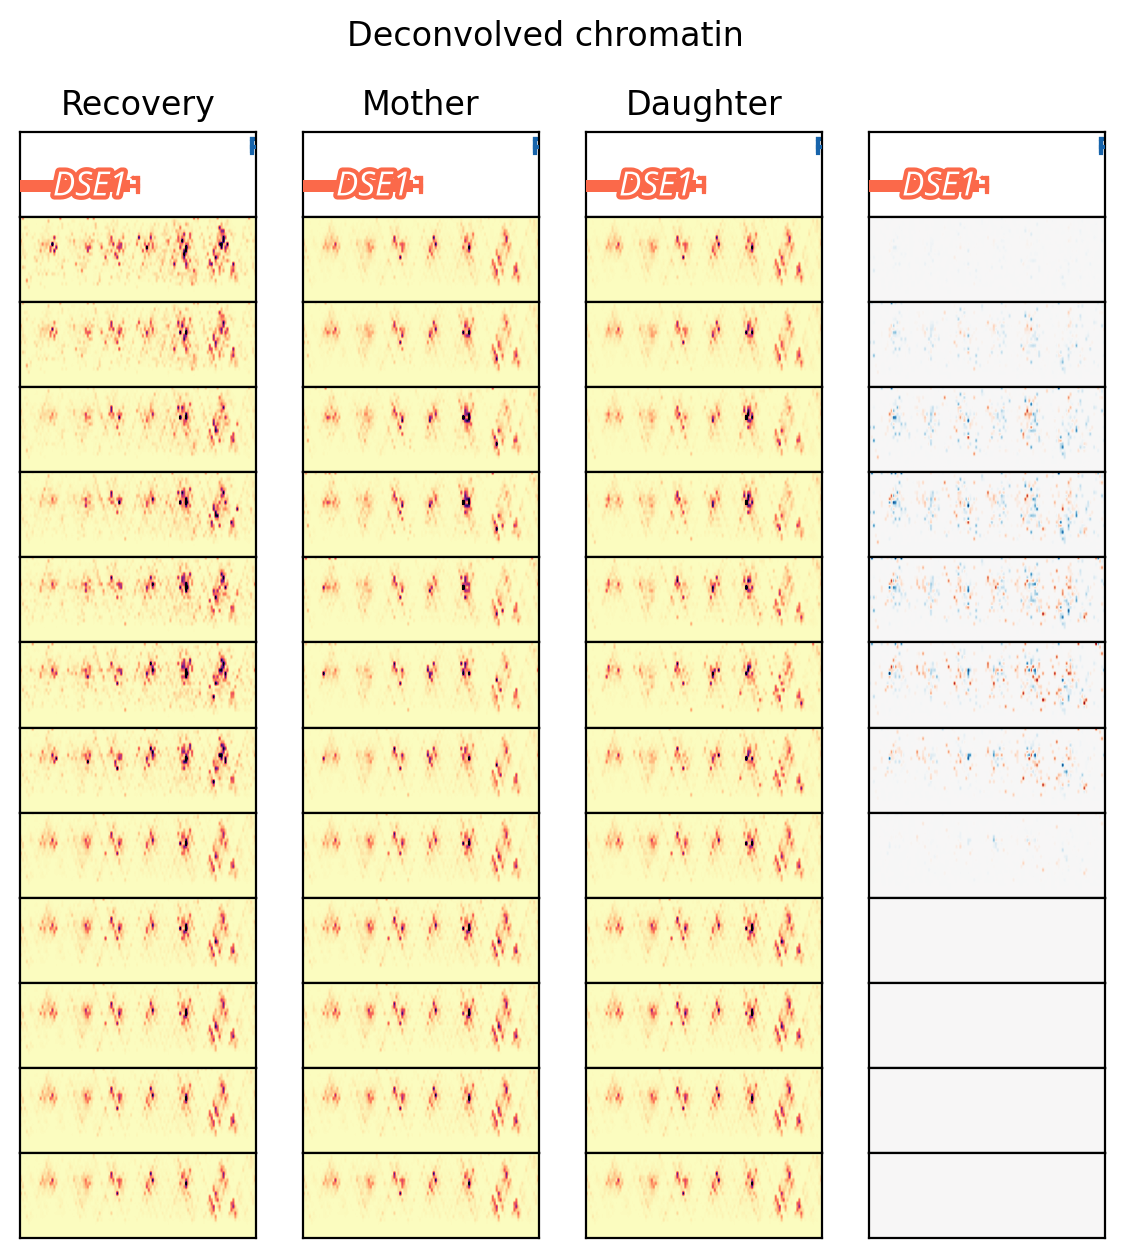

In [953]:
from src.chromatin_deconvolution_solver import plot_branches
fig = plot_branches(config1, chrom, mnase_span, 
                    full_deconvolved_F_genic, figsize=(7, 7))


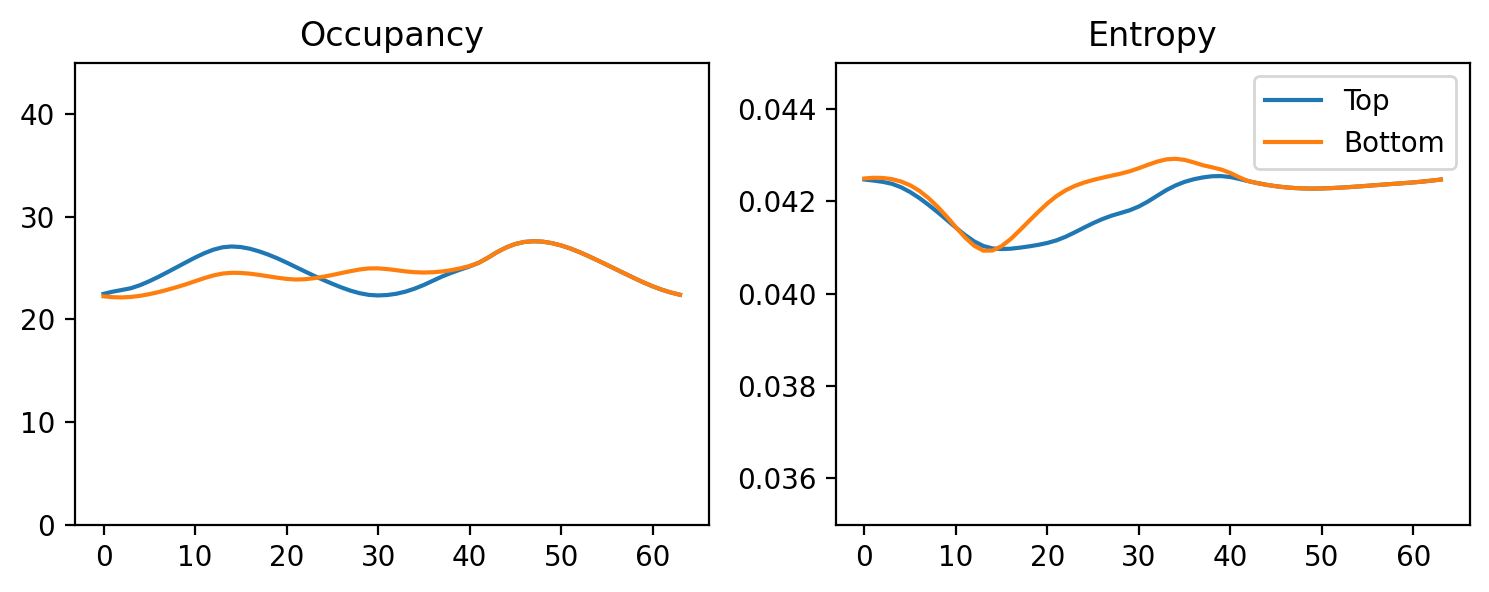

In [954]:
plot_occupancy_and_entropy(config1, full_deconvolved_F_genic)

In [955]:
# gamma = 0.0076
# kappa = 0.0016

In [956]:
gene_name = 'PDR18'
genes = get_deconvolved_geneset()
orfname = get_orfname(gene_name)
gene = genes.loc[orfname]
chrom = gene.chr
mid = gene.TSS

mnase_span = mid-padding_2, mid+padding_2

chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)
chromatin_solver = ChromatinDeconvolveSolver(config1, 
    chromatin_model.G, N, b, frep)
full_deconvolved_F_intergenic = chromatin_solver.deconvolve_G_iteratively(gamma=gamma, 
    kappa=kappa, verbose=True)

Loading chromosome reads: 14
Applying a normalization for length distribution
0/3120 - 00:00:00.001
500/3120 - 00:00:02.538
1000/3120 - 00:00:58.032
1500/3120 - 00:02:20.398
2000/3120 - 00:03:44.314
2500/3120 - 00:05:03.630
3000/3120 - 00:06:17.666
Completed - 00:06:25.267


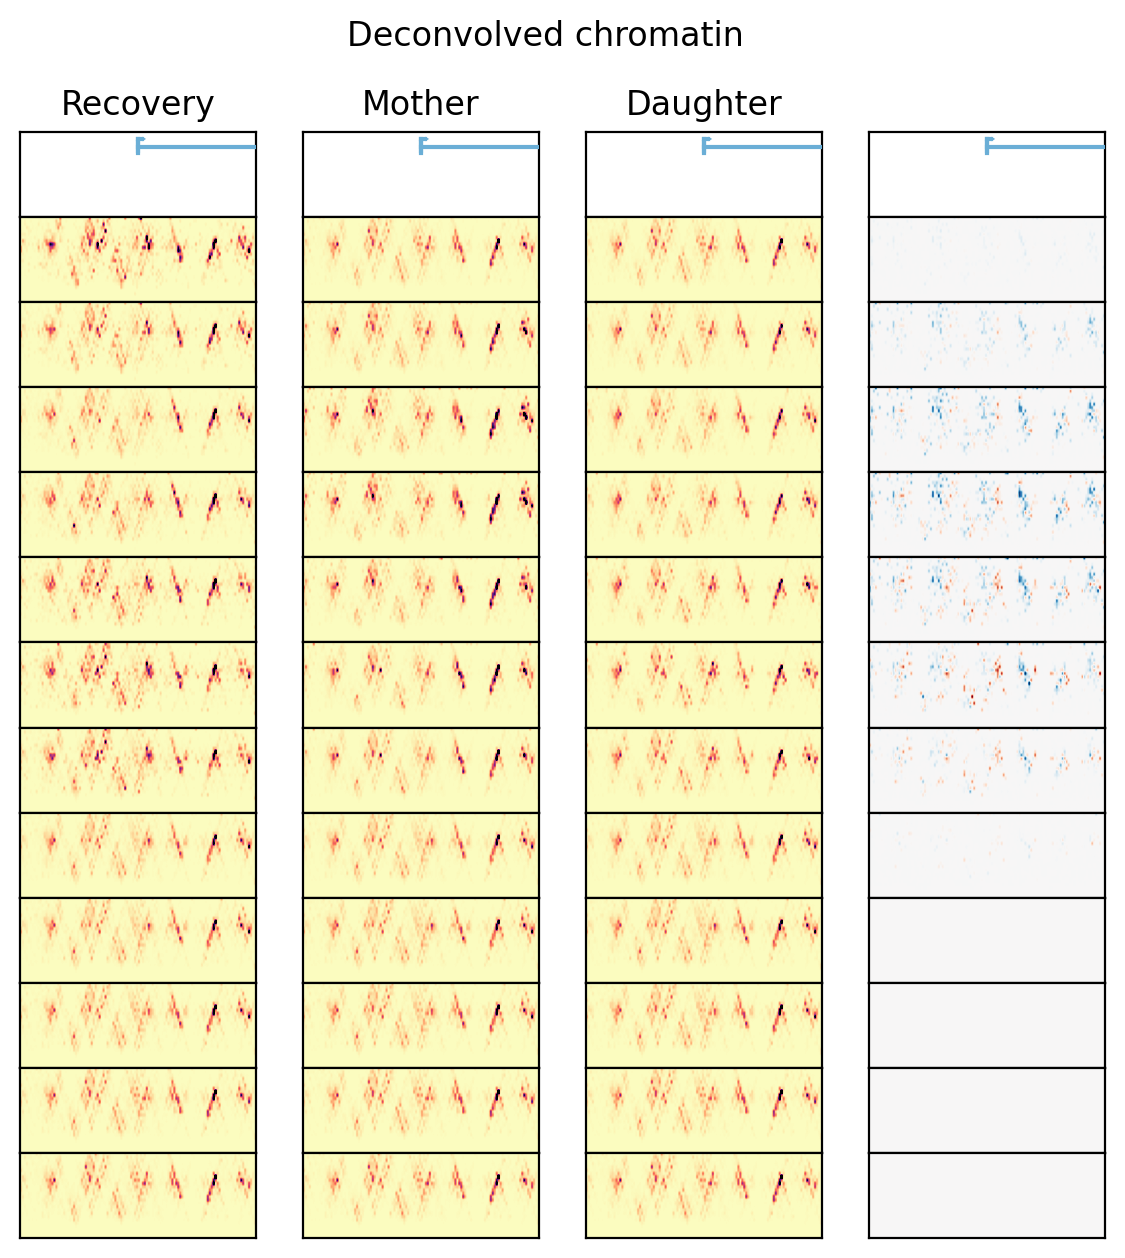

In [957]:
from src.chromatin_deconvolution_solver import plot_branches
fig = plot_branches(config1, chrom, mnase_span, full_deconvolved_F_intergenic, 
                    figsize=(7, 7))

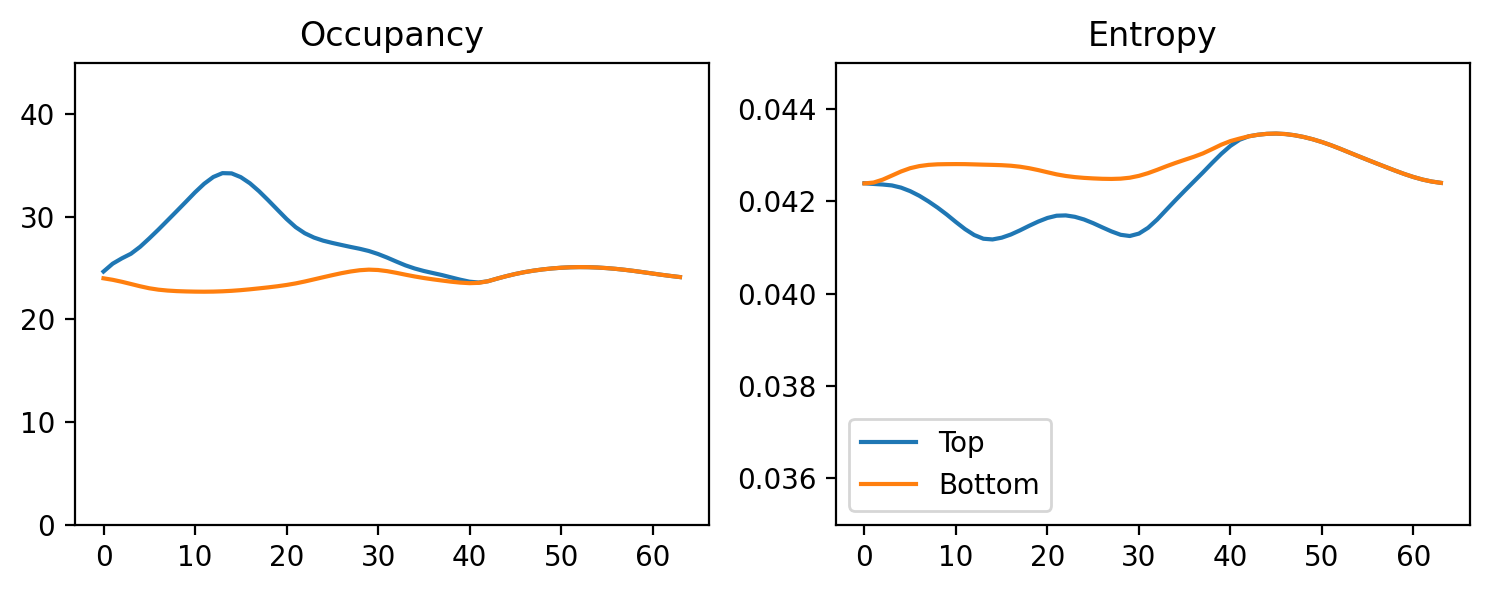

In [958]:
plot_occupancy_and_entropy(config1, full_deconvolved_F_intergenic)